In [ ]:
Classification dataset

**Code for classification modeling**

In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression

plt.rcParams['figure.dpi'] = 120
print('Setup complete!')

Setup complete!



Train: 480 samples | Test: 120 samples
Train accuracy (Logistic): 0.6375
Test accuracy (Logistic):  0.6333


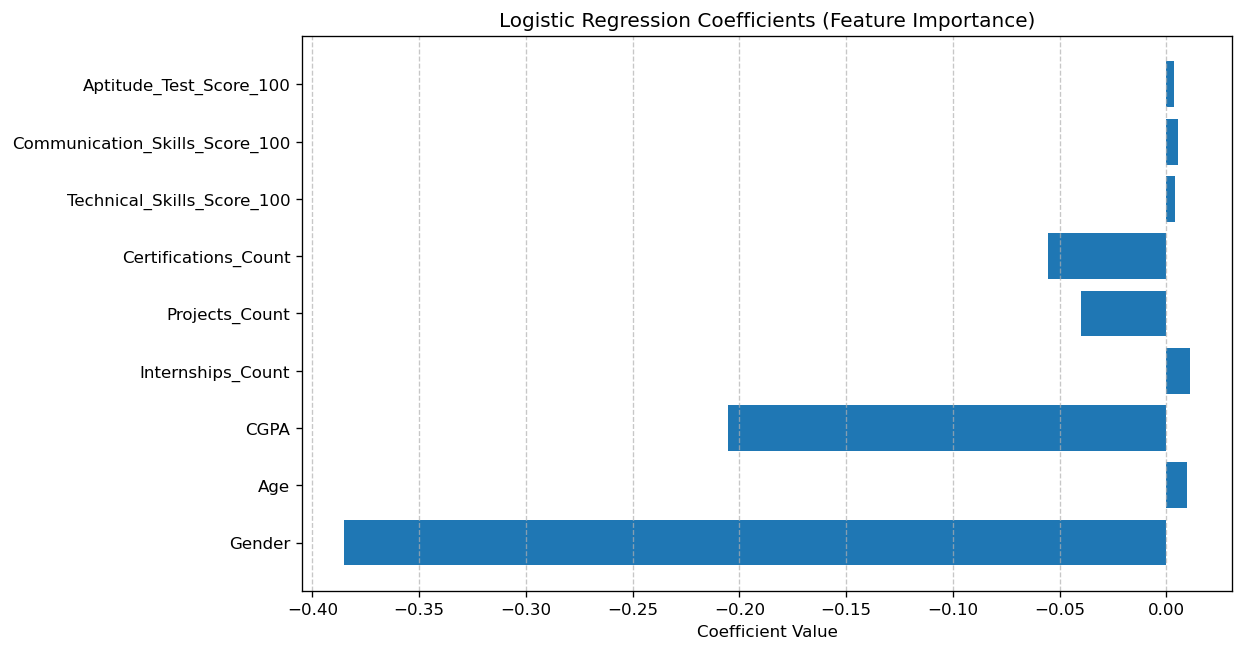

In [161]:
#Load data from pre-processing
df = pd.read_csv('classification_encoded.csv')

#Define all Features to be used, and the test target
feature_cols = [
    'Gender',
    'Age',
    'CGPA',
    'Internships_Count',
    'Projects_Count',
    'Certifications_Count',
    'Technical_Skills_Score_100',
    'Communication_Skills_Score_100',
    'Aptitude_Test_Score_100'
]
X = df[feature_cols]
y = df['Placement_Offer']

#80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=123,
    stratify=y
)

print(f'\nTrain: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')

#Train Logistic Regression
clf = LogisticRegression(max_iter=1000, random_state=123)
clf.fit(X_train, y_train)

#Evaluate accuracy
train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc = accuracy_score(y_test, clf.predict(X_test))
print(f'Train accuracy (Logistic): {train_acc:.4f}')
print(f'Test accuracy (Logistic):  {test_acc:.4f}')

# Instead of plot_tree, you can view the importance of each feature (Coefficients)

plt.figure(figsize=(10, 6))
plt.barh(feature_cols, clf.coef_[0])
plt.title('Logistic Regression Coefficients (Feature Importance)')
plt.xlabel('Coefficient Value')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


Train: 480 samples | Test: 120 samples
Train accuracy (3 features): 0.6646
Test accuracy (3 features):  0.6333


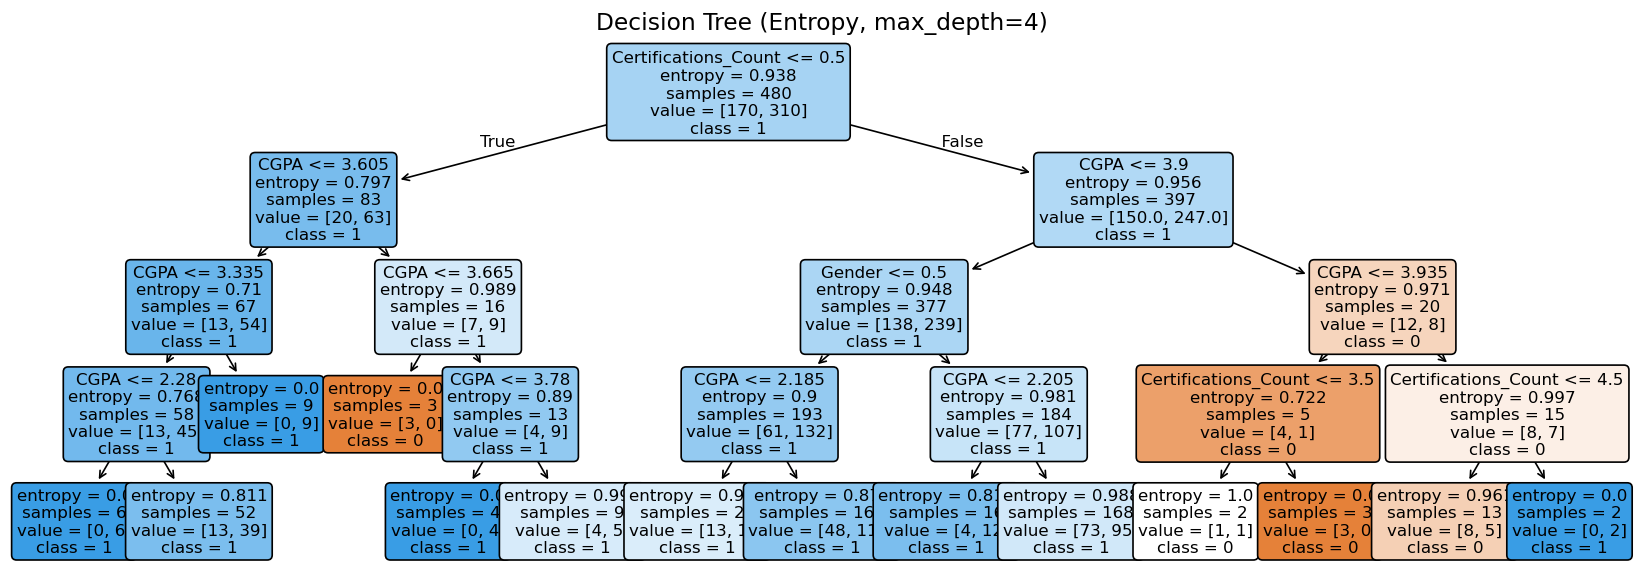

In [164]:
#Load data from pre-processing
df = pd.read_csv('classification_encoded.csv')

#Top 3 features from logreg
feature_cols = [
    'CGPA',
    'Certifications_Count',
    'Gender'
]
X = df[feature_cols]
y = df['Placement_Offer']

#80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=123,
    stratify=y
)

print(f'\nTrain: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')

#Train decision tree
clf = DecisionTreeClassifier(
    criterion='entropy', 
    max_depth=4, 
    random_state=123
)
clf.fit(X_train, y_train)

#Evaluate accuracy
train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc = accuracy_score(y_test, clf.predict(X_test))
print(f'Train accuracy (3 features): {train_acc:.4f}')
print(f'Test accuracy (3 features):  {test_acc:.4f}')

plt.figure(figsize=(14, 5))
plot_tree(clf,
          feature_names=feature_cols,
          class_names=["0", "1"],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree (Entropy, max_depth=4)', fontsize=14)
plt.tight_layout()
plt.show()


Train: 480 samples | Test: 120 samples
Train accuracy (3 features): 0.6729
Test accuracy (3 features):  0.5583


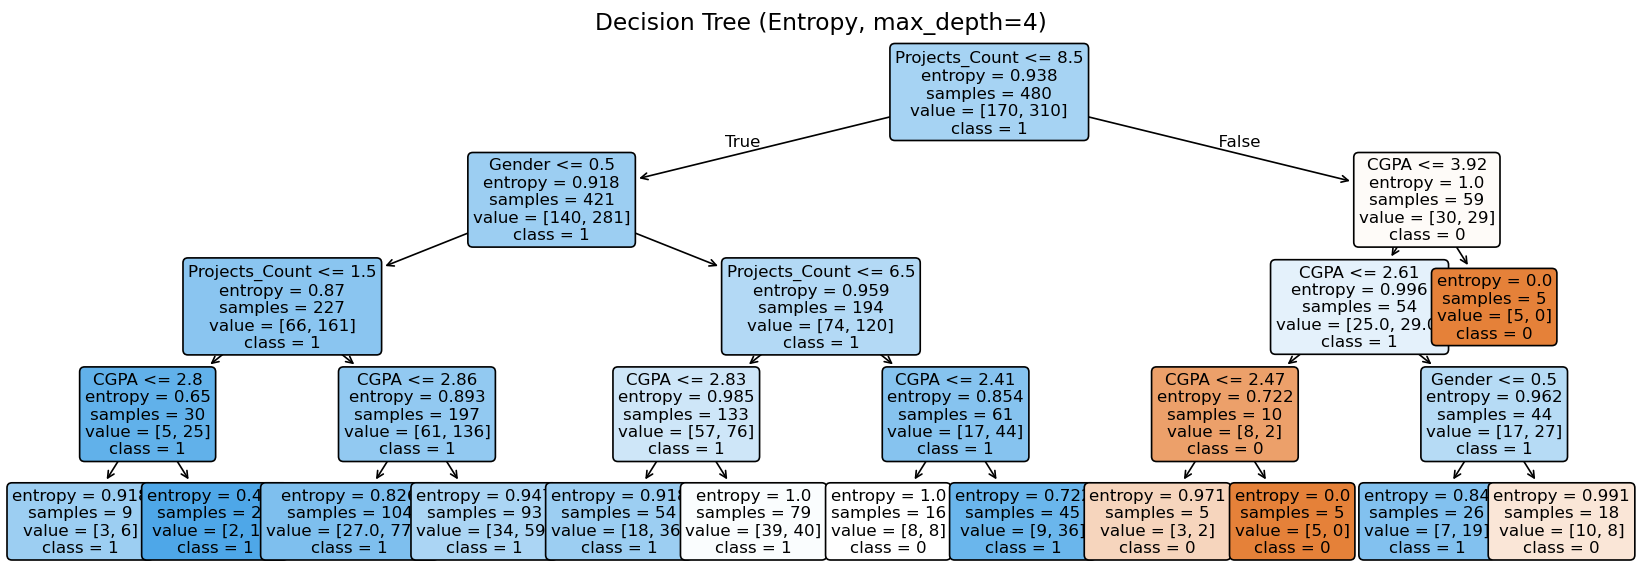

In [165]:
#Load data from pre-processing
df = pd.read_csv('classification_encoded.csv')

#Trial 2, changed cert count to proj count
feature_cols = [
    'CGPA',
    'Projects_Count',
    'Gender'
]
X = df[feature_cols]
y = df['Placement_Offer']

#80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=123,
    stratify=y
)

print(f'\nTrain: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')

#Train decision tree
clf = DecisionTreeClassifier(
    criterion='entropy', 
    max_depth=4, 
    random_state=123
)
clf.fit(X_train, y_train)

#Evaluate accuracy
train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc = accuracy_score(y_test, clf.predict(X_test))
print(f'Train accuracy (3 features): {train_acc:.4f}')
print(f'Test accuracy (3 features):  {test_acc:.4f}')

plt.figure(figsize=(14, 5))
plot_tree(clf,
          feature_names=feature_cols,
          class_names=["0", "1"],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree (Entropy, max_depth=4)', fontsize=14)
plt.tight_layout()
plt.show()


Train: 480 samples | Test: 120 samples
Train accuracy (3 features): 1.0000
Test accuracy (3 features):  0.6250


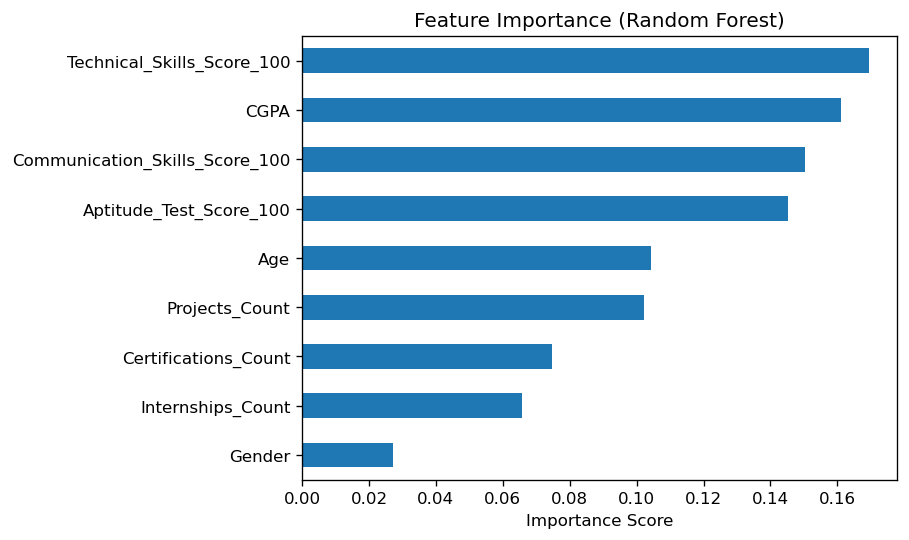

In [167]:
#Random forest - With all features
#Load data from pre-processing
df = pd.read_csv('classification_encoded.csv')

#Define all Features to be used, and the test target
feature_cols = [
    'Gender',
    'Age',
    'CGPA',
    'Internships_Count',
    'Projects_Count',
    'Certifications_Count',
    'Technical_Skills_Score_100',
    'Communication_Skills_Score_100',
    'Aptitude_Test_Score_100'
]
X = df[feature_cols]
y = df['Placement_Offer']

#50/50 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=123,
    stratify=y
)

print(f'\nTrain: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')

# Train Random Forest
clf = RandomForestClassifier(
    n_estimators=100,      # number of trees
    class_weight='balanced',
    random_state=123
)
clf.fit(X_train, y_train)

importances = clf.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values()

#Evaluate accuracy
train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc = accuracy_score(y_test, clf.predict(X_test))
print(f'Train accuracy (3 features): {train_acc:.4f}')
print(f'Test accuracy (3 features):  {test_acc:.4f}')

feat_imp.plot(kind='barh')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.show()